<a href="https://colab.research.google.com/github/APMAPM1/Tech-Gadget-Consumption_2015-2025/blob/develop%2Ftech_gadget_consumption/Tech_Gadget_Consumption_(2015_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tech Gadget Consumption (2015 - 2025)**

**Overview**

Technology adoption has been evolving rapidly, shaping industries and consumer behaviors worldwide. This project leverages a dataset covering global gadget consumption trends from 2015 to 2025.

The data encompasses key technologies such as smartphones, laptops, gaming consoles, smartwatches, and the rising adoption of 5G. Your task as an intern will be to apply machine learning techniques to evaluate and forecast trends using the provided dataset.

**Dataset Description**

- Country: Country where data is recorded 🌍
- Year: Year of observation 📅
- Smartphone Sales (Million): Number of smartphones sold (in millions) 📱
- Laptop Shipments (Million): Number of laptops shipped (in millions) 💻
- Gaming Console Adoption (%): Percentage of population using gaming consoles 🎮
- Smartwatch Penetration (%): Percentage of population using smartwatches ⌚
- Avg Consumer Spending ($): Average spending on tech gadgets 💵
- E-Waste Generation (KT): E-waste generated in kilotons (KT) ♻️
- 5G Penetration (%): Percentage of population with 5G access 📡


# **Loading Dataset and data collection**

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
from google.colab import drive

In [57]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
file_path = '/content/drive/MyDrive/Datasets/Global_Tech_Gadget_Consumption.csv'

In [59]:
df = pd.read_csv(file_path)
df.head()

,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
0,USA,2015,111.37,123.63,12.05,14.49,311.21,939.89,54.64
1,USA,2016,224.65,65.27,12.92,9.88,250.46,1361.42,53.61
2,USA,2017,102.12,26.75,19.63,17.35,2404.22,872.52,29.94
3,USA,2018,148.10,129.28,26.44,12.45,1883.37,1241.41,75.88
4,USA,2019,83.93,97.81,20.84,6.18,777.42,1939.39,76.26


In [60]:
df.columns

Index(['Country', 'Year', 'Smartphone Sales (Millions)',
       'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)',
       'Smartwatch Penetration (%)',
       'Average Consumer Spending on Gadgets ($)',
       'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)'],
      dtype='object')

In [61]:
df.shape

(110, 9)

In [62]:
df.describe()

,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
count,110.00000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000
mean,2020.00000,269.095545,86.082000,21.753545,14.129818,1571.539182,1035.352636,42.816273
std,3.17675,128.313552,36.429392,9.748557,6.353190,816.552255,562.591157,21.888573
min,2015.00000,64.000000,20.790000,5.490000,2.040000,220.090000,111.470000,2.990000
25%,2017.00000,156.910000,59.412500,13.737500,8.982500,856.957500,570.250000,23.952500
50%,2020.00000,253.435000,87.450000,20.365000,14.520000,1592.145000,1023.270000,45.735000
75%,2023.00000,376.255000,113.965000,28.460000,19.815000,2195.960000,1487.847500,58.900000
max,2025.00000,499.890000,149.210000,39.470000,24.810000,2989.540000,1962.590000,79.340000


In [63]:
df.describe(include=['object'])

,Country
count,110
unique,10
top,USA
freq,11


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   110 non-null    object 
 1   Year                                      110 non-null    int64  
 2   Smartphone Sales (Millions)               110 non-null    float64
 3   Laptop Shipments (Millions)               110 non-null    float64
 4   Gaming Console Adoption (%)               110 non-null    float64
 5   Smartwatch Penetration (%)                110 non-null    float64
 6   Average Consumer Spending on Gadgets ($)  110 non-null    float64
 7   E-Waste Generated (Metric Tons)           110 non-null    float64
 8   5G Penetration Rate (%)                   110 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 7.9+ KB


In [65]:
df.nunique()

,0
Country,10
Year,11
Smartphone Sales (Millions),109
Laptop Shipments (Millions),110
Gaming Console Adoption (%),106
Smartwatch Penetration (%),108
Average Consumer Spending on Gadgets ($),110
E-Waste Generated (Metric Tons),110
5G Penetration Rate (%),110


# **Data Preparation**

In [66]:
df.isnull().sum()

,0
Country,0
Year,0
Smartphone Sales (Millions),0
Laptop Shipments (Millions),0
Gaming Console Adoption (%),0
Smartwatch Penetration (%),0
Average Consumer Spending on Gadgets ($),0
E-Waste Generated (Metric Tons),0
5G Penetration Rate (%),0


In [67]:
df.duplicated().sum()

np.int64(0)

## **Data Insights**

Overall Insights

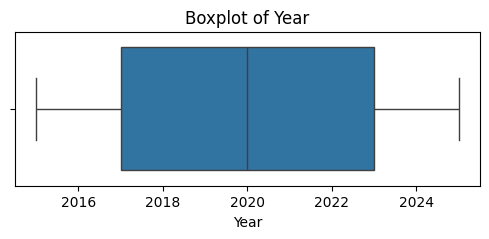

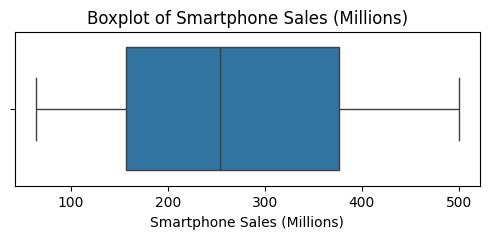

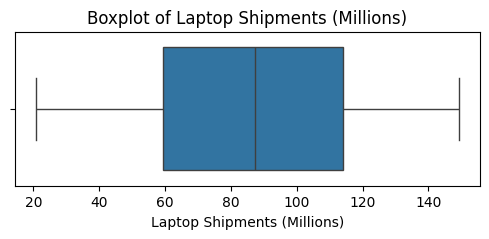

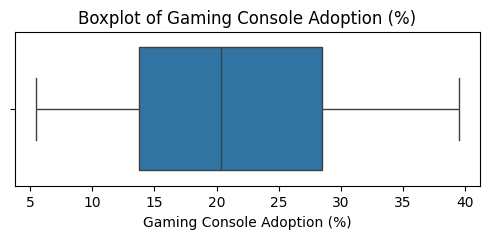

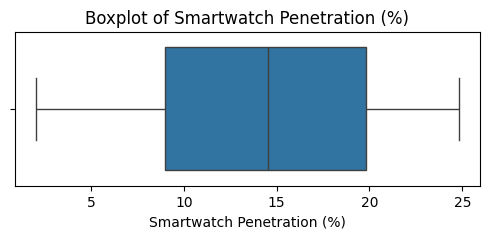

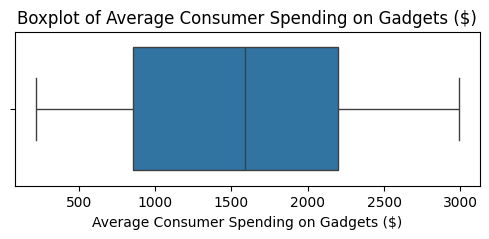

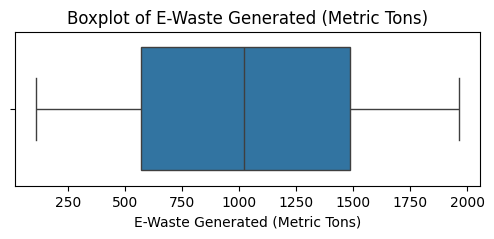

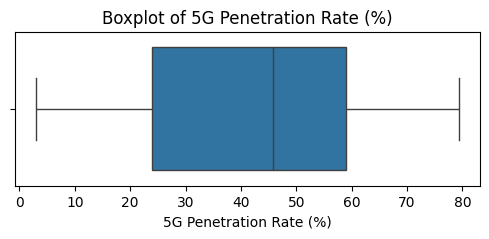

In [68]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
for col in numerical_cols:
  plt.figure(figsize=(6, 2))
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

<ipython-input-69-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-69-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-69-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-69-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-69-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-69-7954fc88395d>:18: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipy

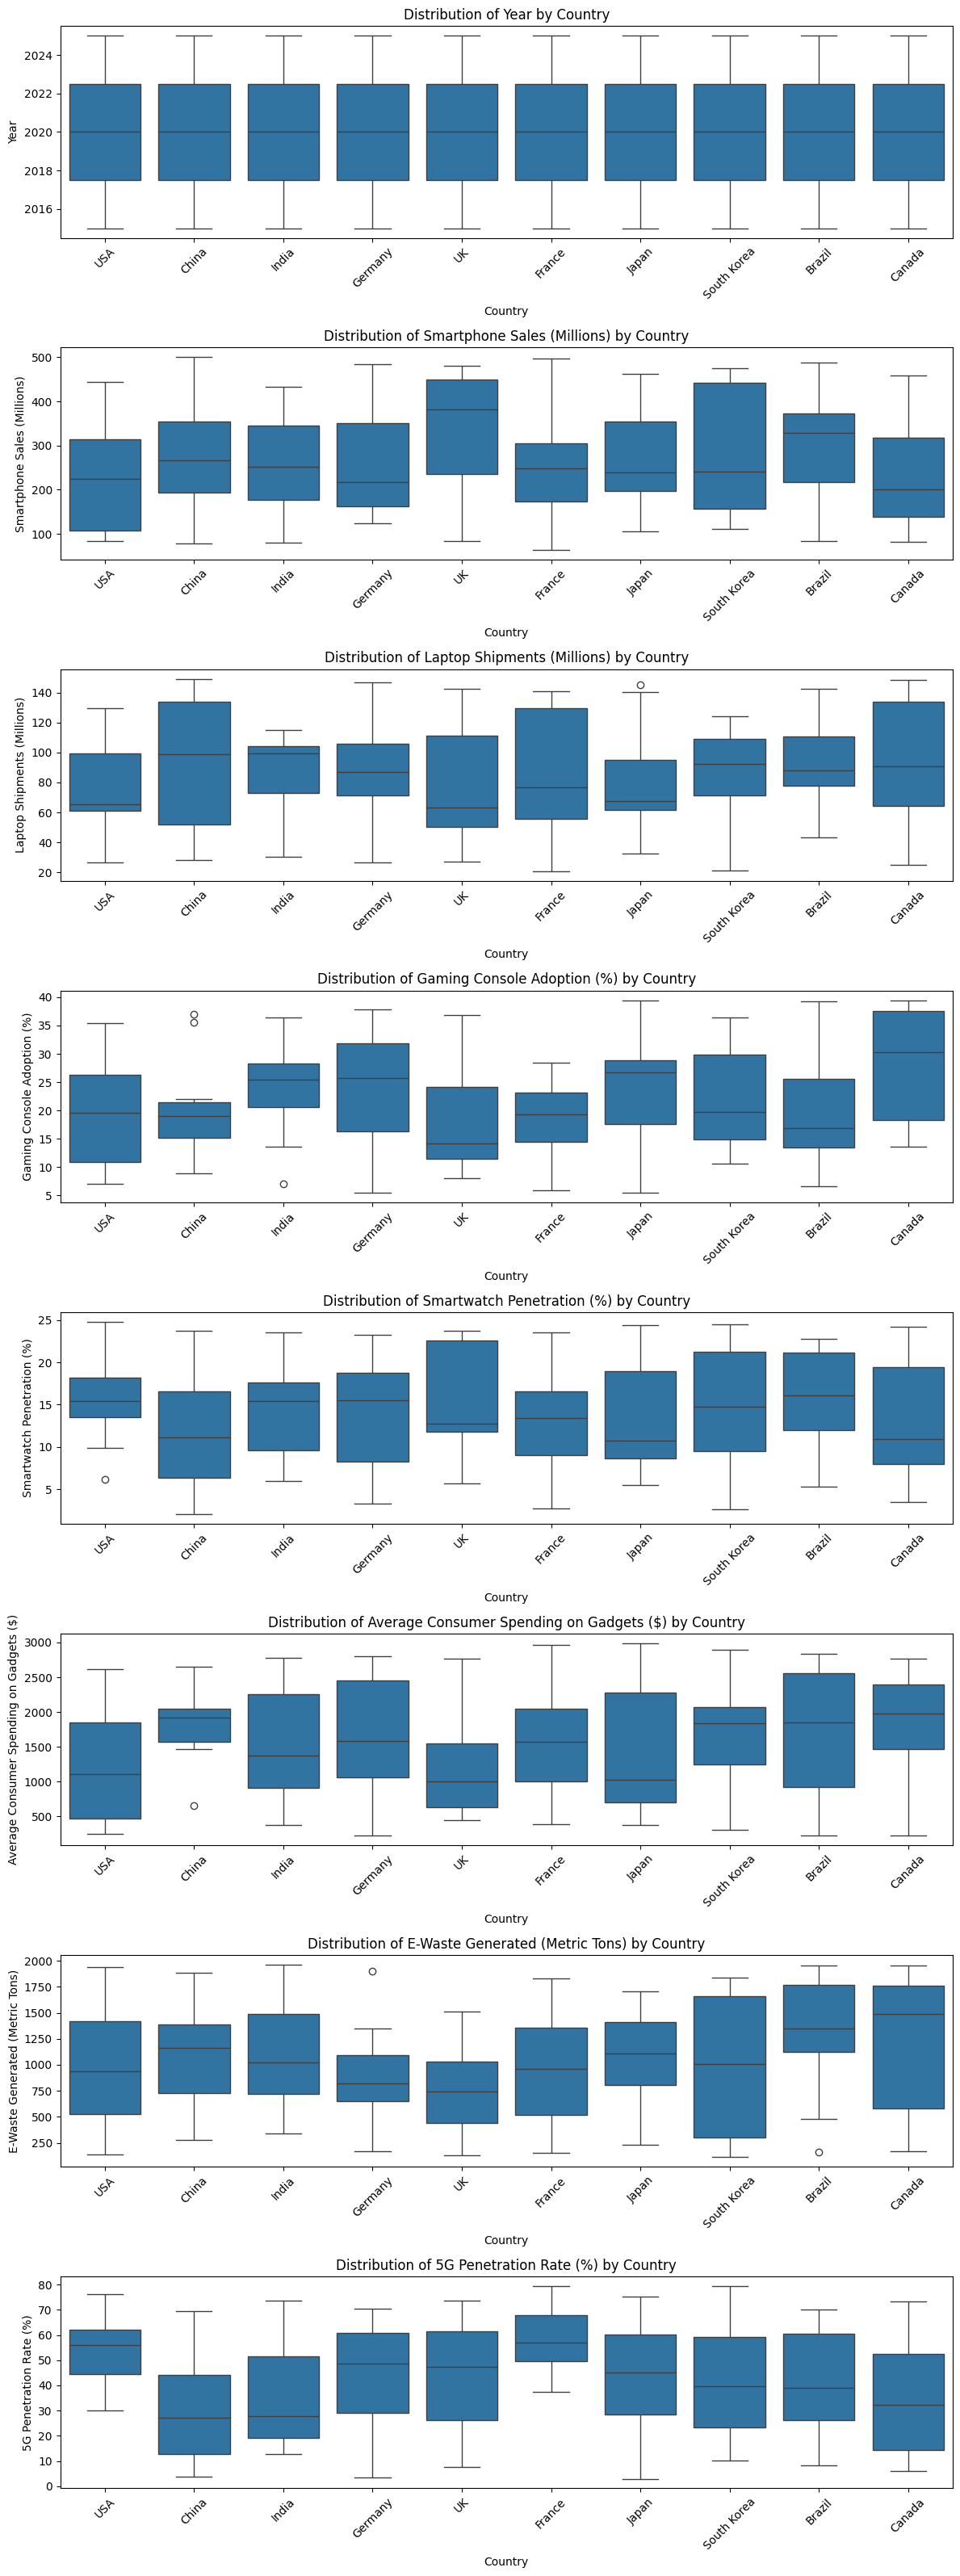

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all numerical columns
numerical_columns = df.select_dtypes(include=["number"]).columns

# Set up the figure size dynamically
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=1, figsize=(12, len(numerical_columns) * 4))

# If there's only one numerical column, make axes iterable
if len(numerical_columns) == 1:
    axes = [axes]

# Generate boxplots for each numerical column
for i, col in enumerate(numerical_columns):
    sns.boxplot(data=df, x="Country", y=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col} by Country")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)  # Rotate x-axis labels

plt.tight_layout()
plt.show()


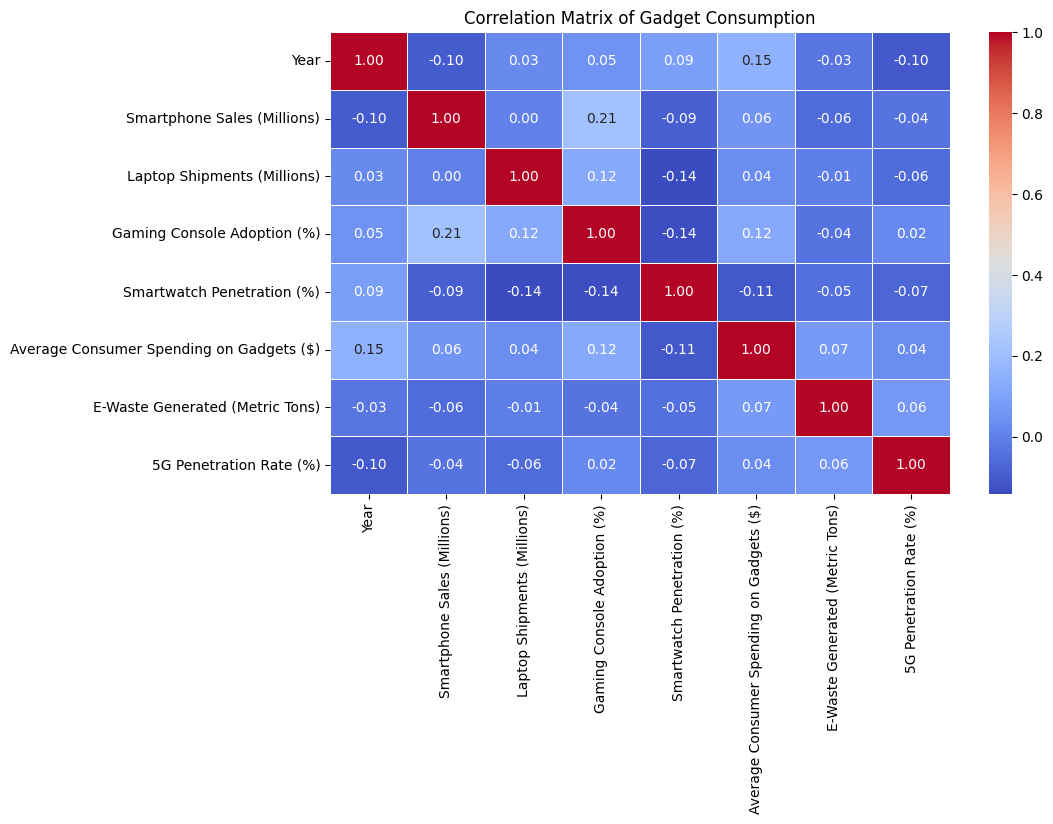

In [70]:
plt.figure(figsize=(10, 6))
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Gadget Consumption")
plt.show()

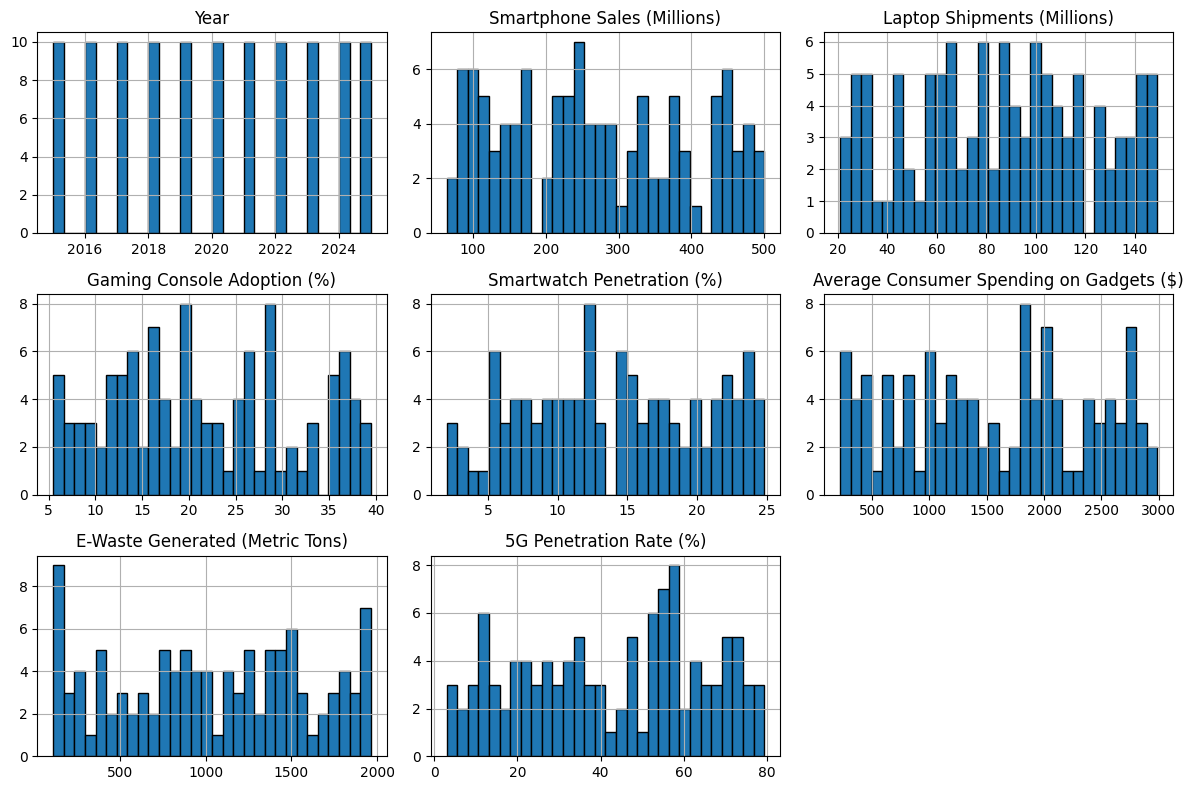

In [71]:
df.hist(figsize=(12, 8), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

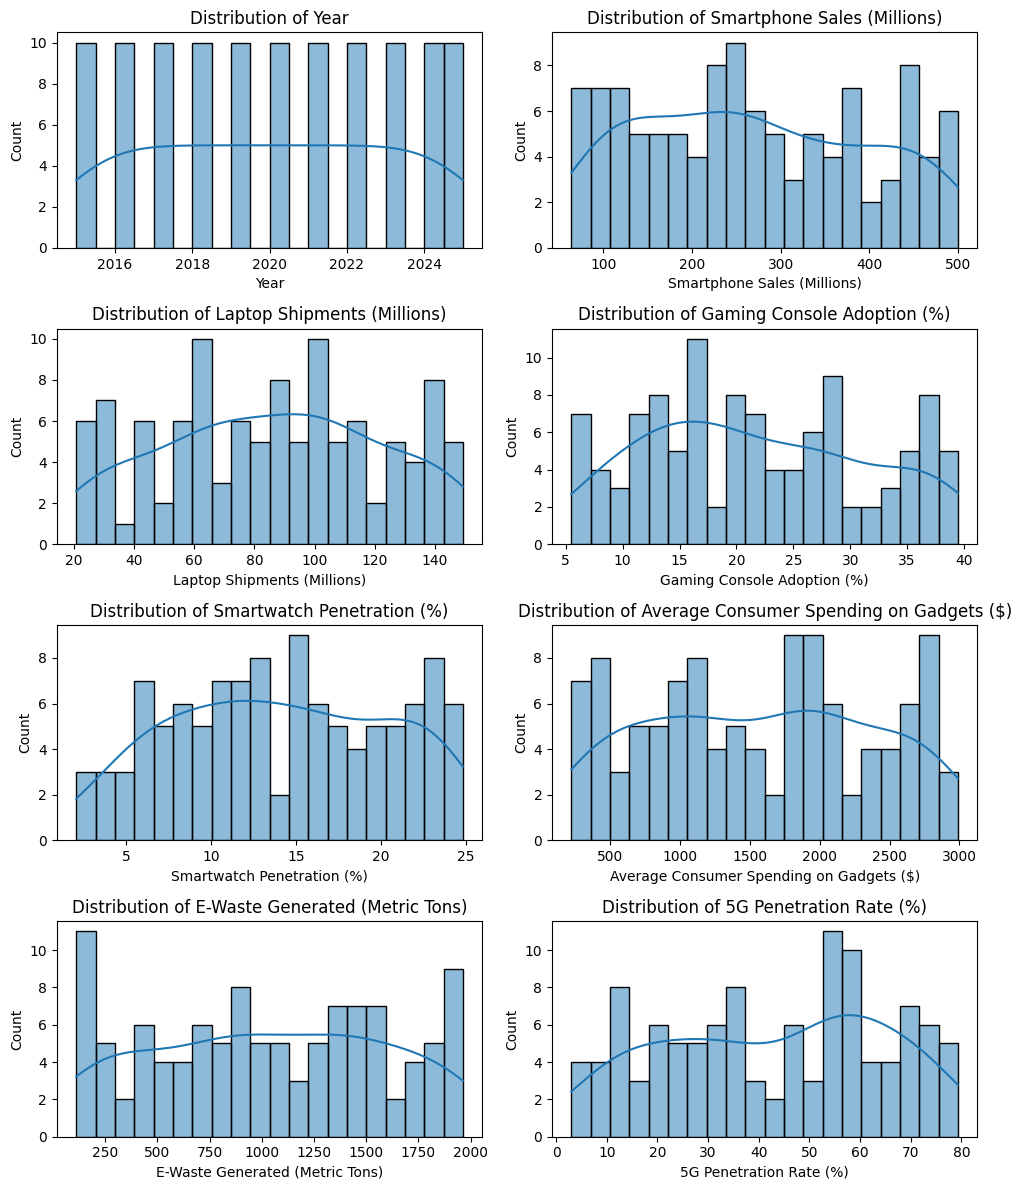

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get all numerical columns
numerical_columns = df.select_dtypes(include=["number"]).columns

# Determine the number of rows and columns dynamically
num_cols = len(numerical_columns)
num_rows = (num_cols // 2) + (num_cols % 2)  # Adjust row count for odd numbers

# Create subplots
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(10, num_rows * 3))
axes = axes.flatten()  # Flatten the axes array for easier iteration

# Plot histograms
for i, col in enumerate(numerical_columns):
    sns.histplot(df[col], bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


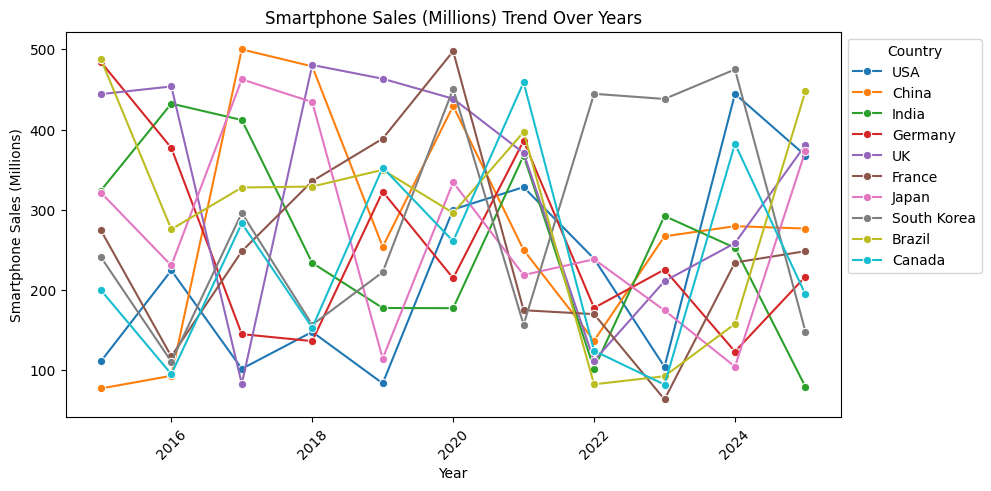

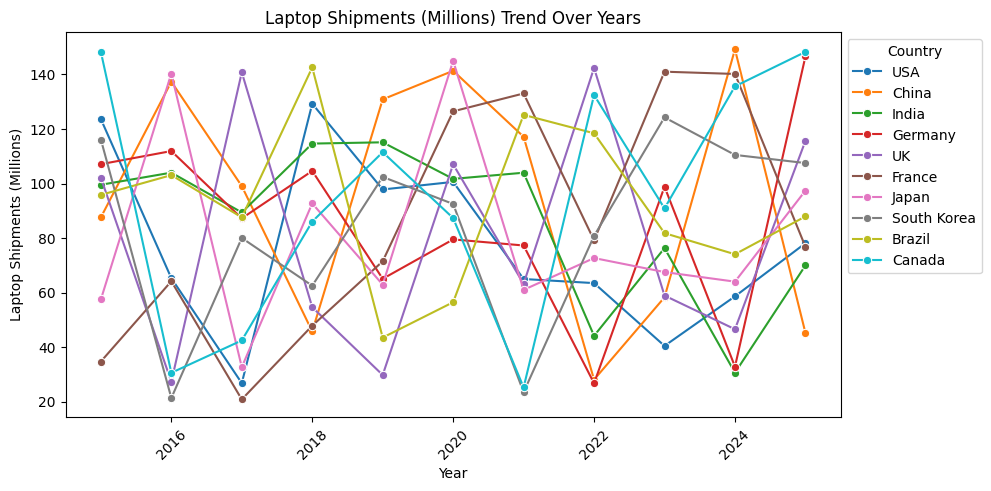

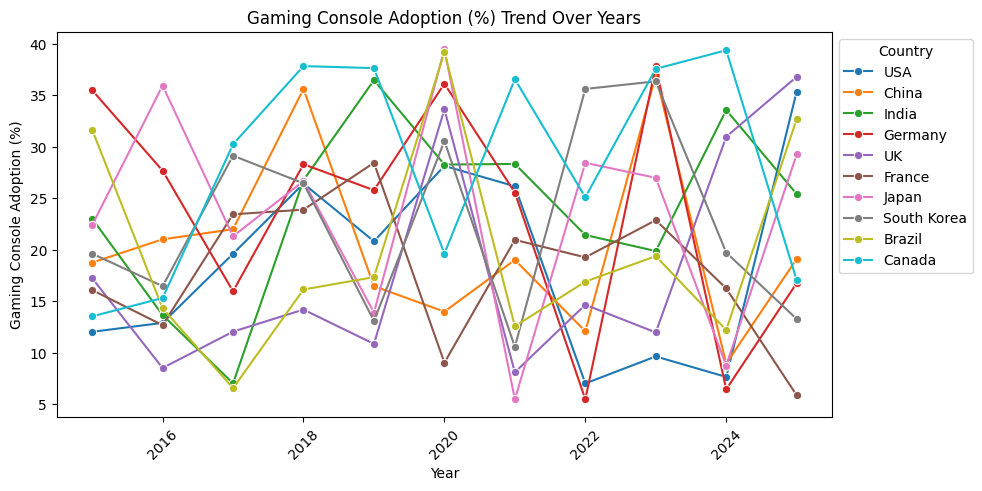

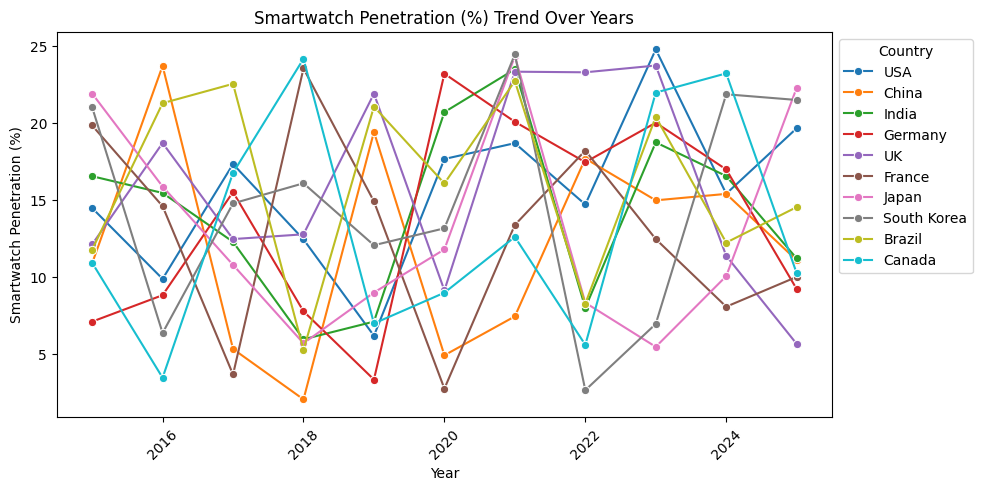

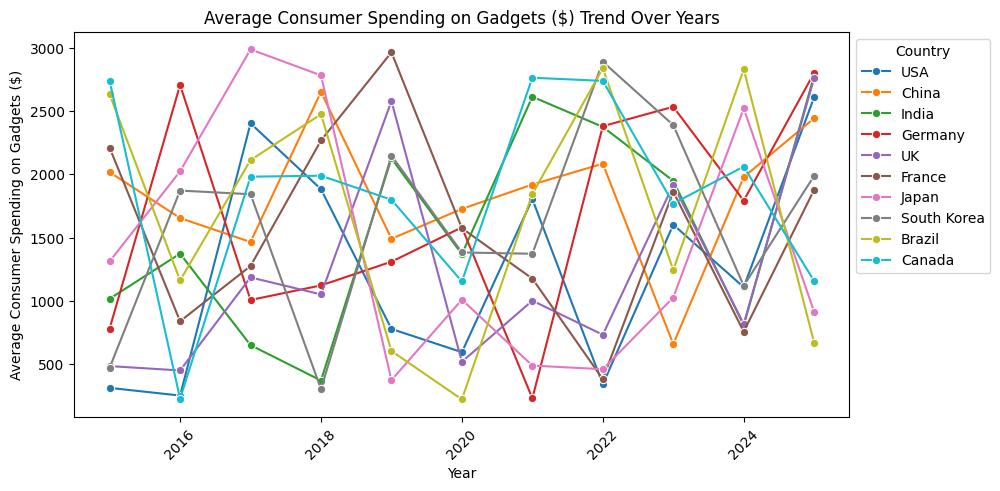

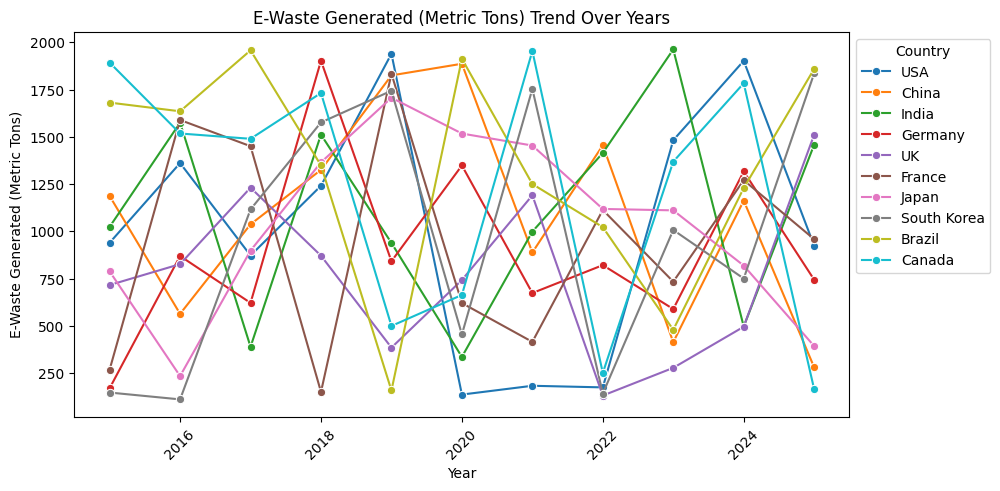

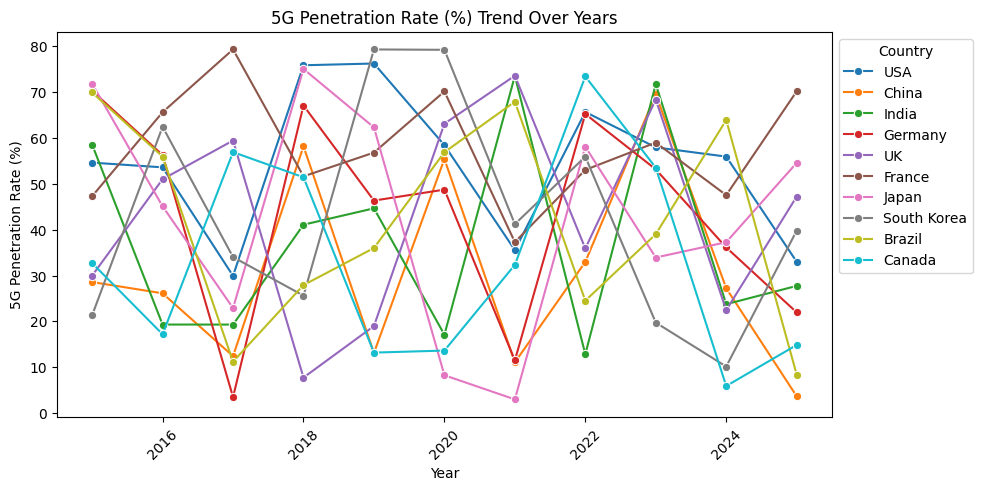

In [73]:
columns_to_plot = [
    "Smartphone Sales (Millions)",
    "Laptop Shipments (Millions)",
    "Gaming Console Adoption (%)",
    "Smartwatch Penetration (%)",
    "Average Consumer Spending on Gadgets ($)",
    "E-Waste Generated (Metric Tons)",
    "5G Penetration Rate (%)"

]

if "Year" in df.columns:
    for col in columns_to_plot:
        if col in df.columns:
            plt.figure(figsize=(10, 5))
            sns.lineplot(x="Year", y=col, data=df, hue="Country", marker="o")
            plt.title(f"{col} Trend Over Years")
            plt.xlabel("Year")
            plt.ylabel(f"{col}")
            plt.xticks(rotation=45)
            plt.legend(title="Country", bbox_to_anchor=(1, 1))
            plt.show()


In [74]:
tech_cols = ['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)',
            'Gaming Console Adoption (%)', 'Smartwatch Penetration (%)',
             'Average Consumer Spending on Gadgets ($)', 'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)']

df_tech = df.groupby('Country')[tech_cols].mean().sort_values(by='Smartphone Sales (Millions)', ascending=False)

df_tech.style.background_gradient(cmap='Blues')

,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
Country,,,,,,,
UK,336.145455,80.740000,18.109091,15.874545,1227.135455,762.036364,43.448182
Brazil,295.027273,92.397273,19.924545,16.030000,1694.451818,1321.446364,41.980909
South Korea,285.612727,83.754545,22.823636,14.639091,1616.678182,967.315455,42.629091
China,276.717273,94.526364,20.375455,12.089091,1827.165455,1093.421818,30.766364
Japan,273.532727,81.231818,23.523636,13.239091,1445.444545,1037.119091,42.949091
India,259.336364,86.298182,24.000909,14.196364,1585.019091,1100.693636,37.246364
Germany,255.564545,85.233636,23.780000,13.600909,1659.245455,900.139091,43.666364
France,250.460909,85.056364,18.090000,12.866364,1562.700909,946.116364,58.003636
Canada,235.370000,94.412727,28.183636,13.183636,1853.297273,1210.844545,33.202727


Individual Columns

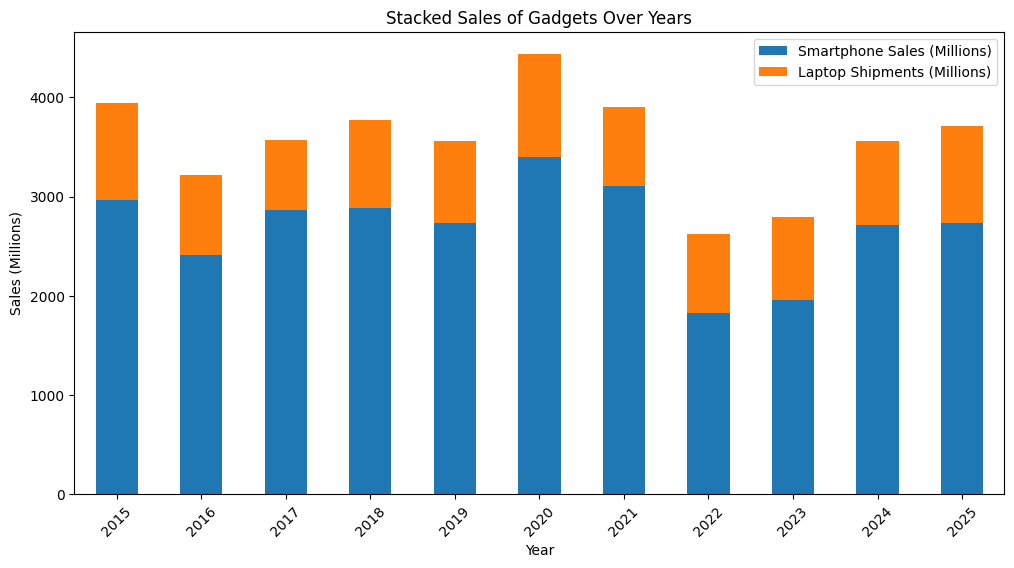

In [75]:
df_grouped = df.groupby("Year")[["Smartphone Sales (Millions)", "Laptop Shipments (Millions)"]].sum()

df_grouped.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Stacked Sales of Gadgets Over Years")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.show()

In [76]:
import plotly.express as px

# Ensure 'Year' is treated as a categorical variable
df["Year"] = df["Year"].astype(str)

# Create animated choropleth map
fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Smartphone Sales (Millions)",
                    hover_name="Country",
                    animation_frame="Year",  # Animation by year
                    title="Smartphone Sales by Country Over Time",
                    color_continuous_scale="viridis")

# Show the figure
fig.show()


In [77]:
import plotly.express as px

# Ensure 'Year' is treated as a categorical variable
df["Year"] = df["Year"].astype(str)

# Create animated choropleth map
fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Laptop Shipments (Millions)",
                    hover_name="Country",
                    animation_frame="Year",  # Animation by year
                    title="Laptop Shipments by Country Over Time",
                    color_continuous_scale="viridis")

# Show the figure
fig.show()


In [78]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

# Gaming Console Adoption Map
fig = px.choropleth(df,
                     locations="Country",
                     locationmode="country names",
                     color="Gaming Console Adoption (%)",
                     hover_name="Country",
                     animation_frame="Year",
                     title="Gaming Console Adoption by Country Over Time",
                     color_continuous_scale="viridis")
fig.show()



In [79]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

# Smartwatch Penetration Map
fig = px.choropleth(df,
                     locations="Country",
                     locationmode="country names",
                     color="Smartwatch Penetration (%)",
                     hover_name="Country",
                     animation_frame="Year",
                     title="Smartwatch Penetration by Country Over Time",
                     color_continuous_scale="plasma")
fig.show()


In [80]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Average Consumer Spending on Gadgets ($)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="Average Consumer Spending on Gadgets by Country Over Time",
                    color_continuous_scale="blues")

fig.show()


In [81]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="E-Waste Generated (Metric Tons)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="E-Waste Generation by Country Over Time",
                    color_continuous_scale="reds")

fig.show()


In [82]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="5G Penetration Rate (%)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="5G Penetration Rate by Country Over Time",
                    color_continuous_scale="plasma")

fig.show()


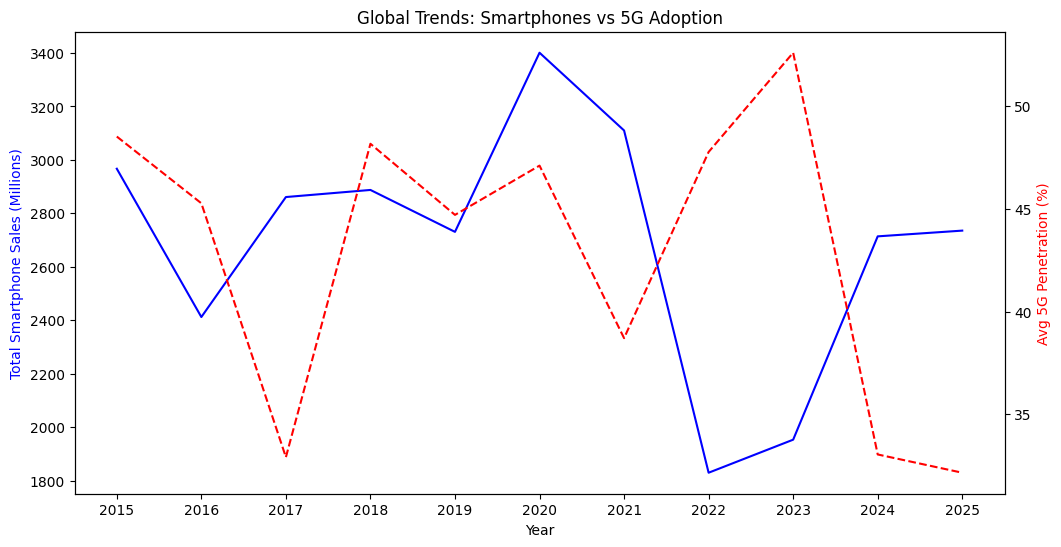

In [83]:
yearly = df.groupby('Year').agg({
    'Smartphone Sales (Millions)': 'sum',
    '5G Penetration Rate (%)': 'mean',
    'E-Waste Generated (Metric Tons)': 'sum'
})

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(yearly.index, yearly['Smartphone Sales (Millions)'], 'b-')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Smartphone Sales (Millions)', color='b')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['5G Penetration Rate (%)'], 'r--')
ax2.set_ylabel('Avg 5G Penetration (%)', color='r')

plt.title("Global Trends: Smartphones vs 5G Adoption")
plt.show()

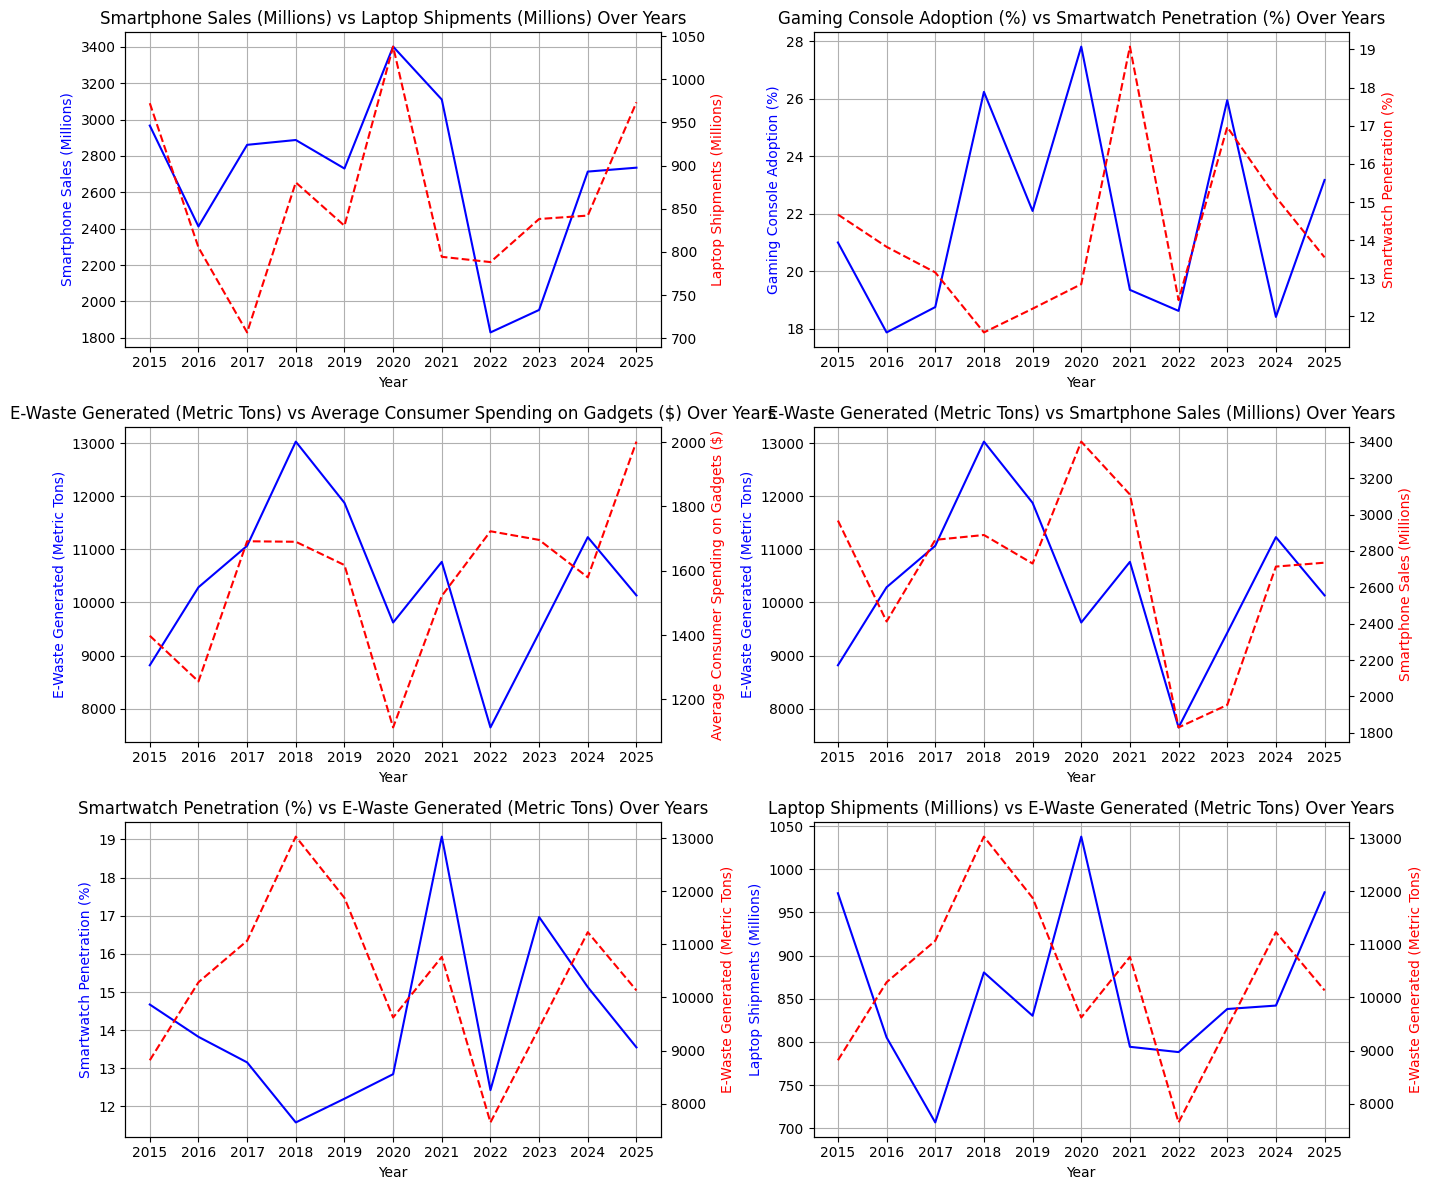

In [84]:
import matplotlib.pyplot as plt

# Group data by Year
yearly = df.groupby('Year').agg({
    'Smartphone Sales (Millions)': 'sum',
    'Laptop Shipments (Millions)': 'sum',
    'Gaming Console Adoption (%)': 'mean',
    'Smartwatch Penetration (%)': 'mean',
    '5G Penetration Rate (%)': 'mean',
    'Average Consumer Spending on Gadgets ($)': 'mean',
    'E-Waste Generated (Metric Tons)': 'sum'
})

# Define column pairs for dual-axis plotting
column_pairs = [
    ('Smartphone Sales (Millions)', 'Laptop Shipments (Millions)'),
    ('Gaming Console Adoption (%)', 'Smartwatch Penetration (%)'),
    ('E-Waste Generated (Metric Tons)', 'Average Consumer Spending on Gadgets ($)'),
    ('E-Waste Generated (Metric Tons)', 'Smartphone Sales (Millions)'),
    ('Smartwatch Penetration (%)', 'E-Waste Generated (Metric Tons)'),
    ('Laptop Shipments (Millions)', 'E-Waste Generated (Metric Tons)')
]

# Plot each pair
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()  # Flatten for easier iteration

for i, (col1, col2) in enumerate(column_pairs):
    ax1 = axes[i]
    ax2 = ax1.twinx()  # Create secondary y-axis

    # Plot first column (e.g., Sales, Shipments, etc.)
    ax1.plot(yearly.index, yearly[col1], 'b-', label=col1)
    ax1.set_xlabel('Year')
    ax1.set_ylabel(col1, color='b')

    # Plot second column (e.g., Adoption %, Spending, etc.)
    ax2.plot(yearly.index, yearly[col2], 'r--', label=col2)
    ax2.set_ylabel(col2, color='r')

    ax1.set_title(f"{col1} vs {col2} Over Years")
    ax1.grid(True)

plt.tight_layout()
plt.show()


In [85]:
df['Year'] = pd.to_numeric(df['Year'])
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Country_Num'] = le.fit_transform(df['Country'])


In [86]:
df['YoY_Smartphone_Growth'] = df.groupby('Country')['Smartphone Sales (Millions)'].pct_change() * 100
df['YoY_Laptop_Growth'] = df.groupby('Country')['Laptop Shipments (Millions)'].pct_change() * 100
df['Smartphone_MA_3yr'] = df.groupby('Country')['Smartphone Sales (Millions)'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df['Device_Penetration_Index'] = ( df['Smartphone Sales (Millions)'] * df['Laptop Shipments (Millions)'] * df['Gaming Console Adoption (%)'] ) ** (1/3)
df['Tech_Adoption_Score'] = (
    0.4 * df['Smartphone Sales (Millions)'] +
    0.3 * df['Laptop Shipments (Millions)'] +
    0.2 * df['Gaming Console Adoption (%)'] +
    0.1 * df['Smartwatch Penetration (%)']
)
numeric_cols = df.select_dtypes(include=np.number).columns
regional_avg = df.groupby('Country')[numeric_cols].transform('mean')
df['Smartphone_Sales_vs_Avg'] = df['Smartphone Sales (Millions)'] / regional_avg['Smartphone Sales (Millions)']
df['5G_Rank'] = df.groupby('Year')['5G Penetration Rate (%)'].rank(ascending=False)
df['E-Waste_per_Device'] = df['E-Waste Generated (Metric Tons)'] / ( df['Smartphone Sales (Millions)'] + df['Laptop Shipments (Millions)'] + 1e-6 )
df['Spending_to_Waste_Ratio'] = df['Average Consumer Spending on Gadgets ($)'] / ( df['E-Waste Generated (Metric Tons)'] + 1 )
df['5G_Momentum'] = df.groupby('Country')['5G Penetration Rate (%)'].diff() / df['Year'].diff()
df['Years_Since_Peak_Smartphones'] = df['Year'] - df.groupby('Country')['Smartphone Sales (Millions)'].transform('idxmax')
df['Total Gadget Shipments'] = df['Smartphone Sales (Millions)'] + df['Laptop Shipments (Millions)']
df['Tech Adoption Index'] = (df['5G Penetration Rate (%)'] + df['Gaming Console Adoption (%)'] + df['Smartwatch Penetration (%)']) / 3


In [87]:
df.head()

,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%),Country_Num,...,Device_Penetration_Index,Tech_Adoption_Score,Smartphone_Sales_vs_Avg,5G_Rank,E-Waste_per_Device,Spending_to_Waste_Ratio,5G_Momentum,Years_Since_Peak_Smartphones,Total Gadget Shipments,Tech Adoption Index
0,USA,2015,111.37,123.63,12.05,14.49,311.21,939.89,54.64,9,...,54.948990,85.496,0.498996,5.0,3.999532,0.330761,NaN,2006,235.00,27.060000
1,USA,2016,224.65,65.27,12.92,9.88,250.46,1361.42,53.61,9,...,57.432914,113.013,1.006550,5.0,4.695847,0.183835,-1.03,2007,289.92,25.470000
2,USA,2017,102.12,26.75,19.63,17.35,2404.22,872.52,29.94,9,...,37.709574,54.534,0.457551,5.0,6.770544,2.752335,-23.67,2008,128.87,22.306667
3,USA,2018,148.10,129.28,26.44,12.45,1883.37,1241.41,75.88,9,...,79.698342,104.557,0.663566,1.0,4.475485,1.515901,45.94,2009,277.38,38.256667
4,USA,2019,83.93,97.81,20.84,6.18,777.42,1939.39,76.26,9,...,55.513601,67.701,0.376050,2.0,10.671234,0.400651,0.38,2010,181.74,34.426667


In [88]:
# Select only numerical columns (excluding categorical like "Country")
numeric_cols = df.select_dtypes(include=['number']).columns

# Check for missing values in numerical columns
missing_values = df[numeric_cols].isnull().sum()
print(missing_values[missing_values > 0])

# Option 1: Fill missing values with the median (only for numerical columns)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Option 2: Drop rows with too many missing values, considering only numerical columns
df.dropna(subset=numeric_cols, thresh=len(numeric_cols) - 2, inplace=True)


YoY_Smartphone_Growth    10
YoY_Laptop_Growth        10
5G_Momentum              10
dtype: int64


In [89]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd


# Select only numerical columns
numeric_cols = df.select_dtypes(include=['number']).columns
df_reduced = df[numeric_cols]


# Apply variance threshold
selector = VarianceThreshold(threshold=0.01)  # Remove features with variance < 1%
selector.fit(df_reduced)


# Get columns that were removed
removed_columns = df_reduced.columns[~selector.get_support()]
print("Removed Columns:", list(removed_columns))


# Keep only selected features
df_reduced = pd.DataFrame(selector.transform(df_reduced), columns=df_reduced.columns[selector.get_support()])


Removed Columns: []


Market Research & Consumer Behavior Analysis

In [90]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.Series(
    [variance_inflation_factor(df.select_dtypes(include=np.number).values, i)
     for i in range(df.select_dtypes(include=np.number).shape[1])],
    index=df.select_dtypes(include=np.number).columns
)
print(vif.sort_values())

YoY_Laptop_Growth                              2.100565
5G_Momentum                                    2.164801
YoY_Smartphone_Growth                          2.829198
Spending_to_Waste_Ratio                        4.371731
Country_Num                                    5.260977
Average Consumer Spending on Gadgets ($)       7.876947
E-Waste_per_Device                            21.725692
E-Waste Generated (Metric Tons)               25.937309
Smartphone_MA_3yr                             35.747363
5G_Rank                                       37.092970
Smartphone_Sales_vs_Avg                      101.674289
Device_Penetration_Index                     301.491916
Years_Since_Peak_Smartphones                5226.505785
Year                                        5304.475081
5G Penetration Rate (%)                             inf
Gaming Console Adoption (%)                         inf
Tech_Adoption_Score                                 inf
Laptop Shipments (Millions)                     

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



Forecasting Future Tech Trends

In [91]:
from statsmodels.tsa.arima.model import ARIMA

# Select a country for forecasting
country = "USA"
usa_data = df[df['Country'] == country].set_index('Year')

# Fit ARIMA model to 5G penetration
model = ARIMA(usa_data['5G Penetration Rate (%)'], order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=5)  # Predict next 5 years
print(forecast)


11    54.198853
12    54.262747
13    54.262940
14    54.262940
15    54.262940
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_mod

Studying the Impact of E-Waste Generation

In [92]:
top_e_waste_countries = df.groupby('Country')['E-Waste_per_Device'].mean().sort_values(ascending=False)
print(top_e_waste_countries.head(5))


Country
Canada    4.464244
USA       4.370820
India     3.953199
Brazil    3.598472
Japan     3.541235
Name: E-Waste_per_Device, dtype: float64


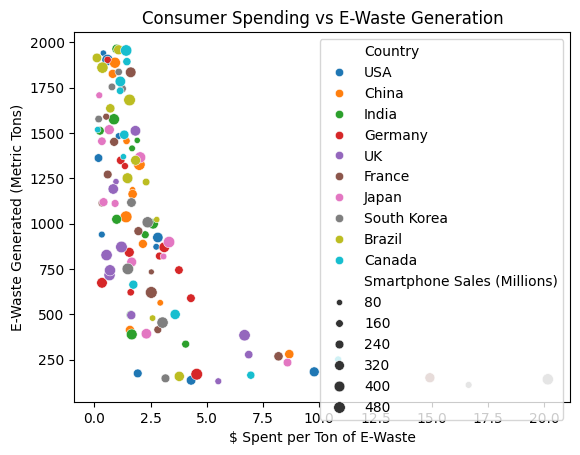

In [93]:
sns.scatterplot(
    data=df,
    x='Spending_to_Waste_Ratio',
    y='E-Waste Generated (Metric Tons)',
    size='Smartphone Sales (Millions)',
    hue='Country'
)
plt.title("Consumer Spending vs E-Waste Generation")
plt.xlabel("$ Spent per Ton of E-Waste");

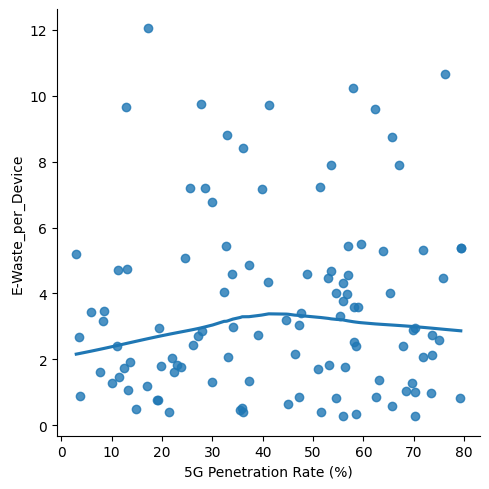

In [94]:
sns.lmplot(
    data=df,
    x='5G Penetration Rate (%)',
    y='E-Waste_per_Device',
    lowess=True
);

Understanding 5G Penetration

In [95]:
top_5g_growth = df.groupby('Country')['5G_Momentum'].mean().sort_values(ascending=False)
print(top_5g_growth.head(5))


Country
France         2.029545
South Korea    1.627727
UK             1.516818
Japan         -1.619545
Canada        -1.674091
Name: 5G_Momentum, dtype: float64


In [96]:
df.head()

,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%),Country_Num,...,Device_Penetration_Index,Tech_Adoption_Score,Smartphone_Sales_vs_Avg,5G_Rank,E-Waste_per_Device,Spending_to_Waste_Ratio,5G_Momentum,Years_Since_Peak_Smartphones,Total Gadget Shipments,Tech Adoption Index
0,USA,2015,111.37,123.63,12.05,14.49,311.21,939.89,54.64,9,...,54.948990,85.496,0.498996,5.0,3.999532,0.330761,-0.555,2006,235.00,27.060000
1,USA,2016,224.65,65.27,12.92,9.88,250.46,1361.42,53.61,9,...,57.432914,113.013,1.006550,5.0,4.695847,0.183835,-1.030,2007,289.92,25.470000
2,USA,2017,102.12,26.75,19.63,17.35,2404.22,872.52,29.94,9,...,37.709574,54.534,0.457551,5.0,6.770544,2.752335,-23.670,2008,128.87,22.306667
3,USA,2018,148.10,129.28,26.44,12.45,1883.37,1241.41,75.88,9,...,79.698342,104.557,0.663566,1.0,4.475485,1.515901,45.940,2009,277.38,38.256667
4,USA,2019,83.93,97.81,20.84,6.18,777.42,1939.39,76.26,9,...,55.513601,67.701,0.376050,2.0,10.671234,0.400651,0.380,2010,181.74,34.426667


In [97]:
# Manually selecting only the desired columns
selected_features = [
    'Country_Num',
    'Year',
    'Laptop Shipments (Millions)',
    'Gaming Console Adoption (%)',
    'Smartwatch Penetration (%)',
    'Average Consumer Spending on Gadgets ($)',
    'E-Waste Generated (Metric Tons)',
    '5G Penetration Rate (%)'
]

# Define feature matrix X and target variable y
X = df[selected_features]
y = df['Smartphone Sales (Millions)']  # Change this to the actual target variable if different

In [98]:
from sklearn.model_selection import train_test_split

# Splitting data: 70% Train, 15% Validation, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}, Test size: {X_test.shape}")


Train size: (77, 8), Validation size: (16, 8), Test size: (17, 8)


In [99]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler = StandardScaler()  # Change to RobustScaler() if outliers exist

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [100]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regressor": SVR()
}

best_model = None
best_rmse = float('inf')

# Train each model and predict
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    rmse = mean_squared_error(y_val, y_pred)  # RMSE

    print(f"📌 **{name}**: RMSE = {rmse:.4f}")

    # Track best model
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model

print(f"\n🏆 **Best Model: {best_model}** with RMSE = {best_rmse:.4f}")


📌 **Linear Regression**: RMSE = 18419.0951
📌 **Ridge Regression**: RMSE = 18356.1193
📌 **Lasso Regression**: RMSE = 18095.7585
📌 **Random Forest**: RMSE = 18286.1567
📌 **Gradient Boosting**: RMSE = 24028.8508
📌 **Support Vector Regressor**: RMSE = 15673.9118

🏆 **Best Model: SVR()** with RMSE = 15673.9118


In [101]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_rmse = float("inf")  # Reset best RMSE
best_model = None          # Reset best model
best_model_name = None  # Store the name of the best model

# Evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)

    # Compute evaluation metrics
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = mse ** 0.5  # RMSE
    r2 = r2_score(y_val, y_pred)

    print(f"📊 **Model: {name}**")
    print(f"➡ Mean Absolute Error (MAE): {mae:.4f}")
    print(f"➡ Mean Squared Error (MSE): {mse:.4f}")
    print(f"➡ Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"➡ R² Score: {r2:.4f}\n")

    # Track best model based on RMSE
    if rmse < best_rmse:
        best_rmse = rmse
        best_model = model
        best_model_name = name  # Save the model name


print(f"🏆 **Best Model: {best_model}** with RMSE = {best_rmse:.4f}")


📊 **Model: Linear Regression**
➡ Mean Absolute Error (MAE): 110.9295
➡ Mean Squared Error (MSE): 18419.0951
➡ Root Mean Squared Error (RMSE): 135.7170
➡ R² Score: -0.2510

📊 **Model: Ridge Regression**
➡ Mean Absolute Error (MAE): 110.6671
➡ Mean Squared Error (MSE): 18356.1193
➡ Root Mean Squared Error (RMSE): 135.4848
➡ R² Score: -0.2467

📊 **Model: Lasso Regression**
➡ Mean Absolute Error (MAE): 110.1681
➡ Mean Squared Error (MSE): 18095.7585
➡ Root Mean Squared Error (RMSE): 134.5205
➡ R² Score: -0.2290

📊 **Model: Random Forest**
➡ Mean Absolute Error (MAE): 110.7315
➡ Mean Squared Error (MSE): 19170.8482
➡ Root Mean Squared Error (RMSE): 138.4588
➡ R² Score: -0.3021

📊 **Model: Gradient Boosting**
➡ Mean Absolute Error (MAE): 117.0429
➡ Mean Squared Error (MSE): 23995.2060
➡ Root Mean Squared Error (RMSE): 154.9039
➡ R² Score: -0.6297

📊 **Model: Support Vector Regressor**
➡ Mean Absolute Error (MAE): 102.3771
➡ Mean Squared Error (MSE): 15673.9118
➡ Root Mean Squared Error (RMSE

In [102]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids
param_grids = {
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    },
    "Gradient Boosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 10]
    }
}

# Dictionary to store tuned models
tuned_models = {}

for model_name in ["Random Forest", "Gradient Boosting"]:
    print(f"\n🔍 **Tuning Hyperparameters for {model_name}**...")

    model = models[model_name]  # Get the base model
    param_grid = param_grids[model_name]  # Get the parameter grid

    # Perform Grid Search with Cross-Validation
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)

    # Store the best tuned model
    tuned_models[model_name] = grid_search.best_estimator_

    print(f"✅ **Best Parameters for {model_name}:** {grid_search.best_params_}")



🔍 **Tuning Hyperparameters for Random Forest**...
✅ **Best Parameters for Random Forest:** {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}

🔍 **Tuning Hyperparameters for Gradient Boosting**...
✅ **Best Parameters for Gradient Boosting:** {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50}


In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dictionary to store evaluation results
evaluation_results = {}

print("\n📊 **Final Model Evaluation After Hyperparameter Tuning**")

# Evaluate each tuned model separately
for name in ["Random Forest", "Gradient Boosting"]:
    model = tuned_models[name]  # Get the tuned model
    model.fit(X_train_scaled, y_train)  # Train the model
    y_pred = model.predict(X_val_scaled)  # Predict on validation set

    # Compute evaluation metrics
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = mse ** 0.5  # RMSE
    r2 = r2_score(y_val, y_pred)

    # Store results in dictionary
    evaluation_results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    }

    print(f"\n🔹 **Model: {name}**")
    print(f"➡ Mean Absolute Error (MAE): {mae:.4f}")
    print(f"➡ Mean Squared Error (MSE): {mse:.4f}")
    print(f"➡ Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"➡ R² Score: {r2:.4f}")

# Compare models based on RMSE
# best_tuned_model = min(evaluation_results, key=lambda x: evaluation_results[x]["RMSE"])
# best_rmse = evaluation_results[best_tuned_model]["RMSE"]

# print(f"\n🏆 **Best Model After Hyperparameter Tuning: {best_tuned_model}** with RMSE = {best_rmse:.4f}")



📊 **Final Model Evaluation After Hyperparameter Tuning**

🔹 **Model: Random Forest**
➡ Mean Absolute Error (MAE): 105.3601
➡ Mean Squared Error (MSE): 17333.6599
➡ Root Mean Squared Error (RMSE): 131.6574
➡ R² Score: -0.1773

🔹 **Model: Gradient Boosting**
➡ Mean Absolute Error (MAE): 103.2846
➡ Mean Squared Error (MSE): 16471.7784
➡ Root Mean Squared Error (RMSE): 128.3424
➡ R² Score: -0.1188


In [104]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Store evaluation results
evaluation_results = {}

# Final model selection (Tuned RF & GB, Untuned SVR)
final_models = {
    "Random Forest": tuned_models["Random Forest"],  # After tuning
    "Gradient Boosting": tuned_models["Gradient Boosting"],  # After tuning
    "SVR": models["Support Vector Regressor"]  # Before tuning
}

print("\n📊 **Final Model Evaluation on Validation & Test Data**")

for name, model in final_models.items():
    # Predictions on Validation Set
    y_val_pred = model.predict(X_val_scaled)

    # Predictions on Test Set
    y_test_pred = model.predict(X_test_scaled)

    # Compute metrics for Validation Set
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_rmse = val_mse ** 0.5
    val_r2 = r2_score(y_val, y_val_pred)

    # Compute metrics for Test Set
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = test_mse ** 0.5
    test_r2 = r2_score(y_test, y_test_pred)

    # Store results
    evaluation_results[name] = {
        "Validation": {
            "MAE": val_mae, "MSE": val_mse, "RMSE": val_rmse, "R² Score": val_r2
        },
        "Test": {
            "MAE": test_mae, "MSE": test_mse, "RMSE": test_rmse, "R² Score": test_r2
        }
    }

    print(f"\n🔹 **Model: {name} (Validation Set)**")
    print(f"➡ Mean Absolute Error (MAE): {val_mae:.4f}")
    print(f"➡ Mean Squared Error (MSE): {val_mse:.4f}")
    print(f"➡ Root Mean Squared Error (RMSE): {val_rmse:.4f}")
    print(f"➡ R² Score: {val_r2:.4f}")

    print(f"\n🔹 **Model: {name} (Test Set)**")
    print(f"➡ Mean Absolute Error (MAE): {test_mae:.4f}")
    print(f"➡ Mean Squared Error (MSE): {test_mse:.4f}")
    print(f"➡ Root Mean Squared Error (RMSE): {test_rmse:.4f}")
    print(f"➡ R² Score: {test_r2:.4f}")



📊 **Final Model Evaluation on Validation & Test Data**

🔹 **Model: Random Forest (Validation Set)**
➡ Mean Absolute Error (MAE): 105.3601
➡ Mean Squared Error (MSE): 17333.6599
➡ Root Mean Squared Error (RMSE): 131.6574
➡ R² Score: -0.1773

🔹 **Model: Random Forest (Test Set)**
➡ Mean Absolute Error (MAE): 127.8741
➡ Mean Squared Error (MSE): 20224.1543
➡ Root Mean Squared Error (RMSE): 142.2117
➡ R² Score: -0.2596

🔹 **Model: Gradient Boosting (Validation Set)**
➡ Mean Absolute Error (MAE): 103.2846
➡ Mean Squared Error (MSE): 16471.7784
➡ Root Mean Squared Error (RMSE): 128.3424
➡ R² Score: -0.1188

🔹 **Model: Gradient Boosting (Test Set)**
➡ Mean Absolute Error (MAE): 128.2803
➡ Mean Squared Error (MSE): 20353.6287
➡ Root Mean Squared Error (RMSE): 142.6661
➡ R² Score: -0.2677

🔹 **Model: SVR (Validation Set)**
➡ Mean Absolute Error (MAE): 102.3771
➡ Mean Squared Error (MSE): 15673.9118
➡ Root Mean Squared Error (RMSE): 125.1955
➡ R² Score: -0.0646

🔹 **Model: SVR (Test Set)**
➡ Me

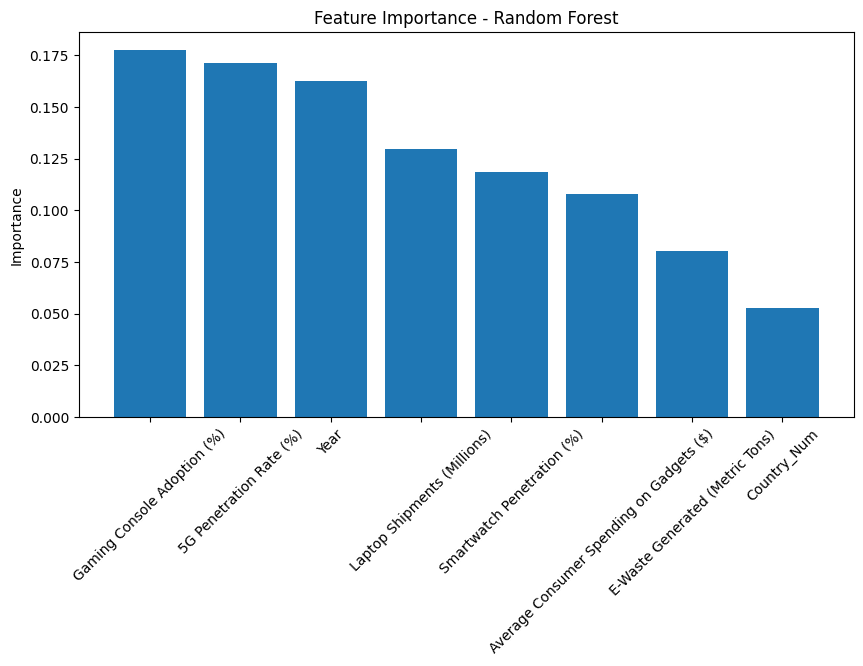

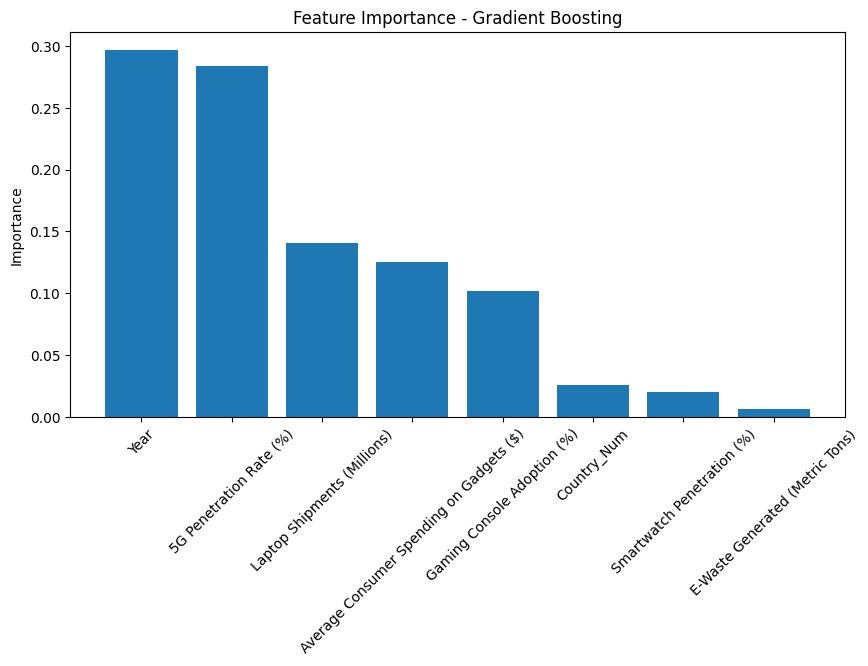

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importance for Random Forest & Gradient Boosting
for name in ["Random Forest", "Gradient Boosting"]:
    model = final_models[name]

    # Get feature importance
    feature_importances = model.feature_importances_
    feature_names = X_train.columns  # Assuming X_train is a DataFrame

    # Sort features by importance
    sorted_idx = np.argsort(feature_importances)[::-1]

    # Plot feature importance
    plt.figure(figsize=(10, 5))
    plt.title(f"Feature Importance - {name}")
    plt.bar(range(len(feature_names)), feature_importances[sorted_idx], align="center")
    plt.xticks(range(len(feature_names)), feature_names[sorted_idx], rotation=45)
    plt.ylabel("Importance")
    plt.show()


In [106]:
import joblib

# Save all three models
for name, model in final_models.items():
    filename = f"{name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(model, filename)
    print(f"💾 {name} model saved successfully as `{filename}`!")


💾 Random Forest model saved successfully as `random_forest_model.pkl`!
💾 Gradient Boosting model saved successfully as `gradient_boosting_model.pkl`!
💾 SVR model saved successfully as `svr_model.pkl`!


In [107]:
import pandas as pd
import numpy as np

# Define feature names (same as used in training)
feature_names = [
    'Country_Num', 'Year', 'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)',
    'Smartwatch Penetration (%)', 'Average Consumer Spending on Gadgets ($)',
    'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)'
]

# Get user input for each selected feature
user_input = [
    float(input(f"Enter {feature}: ")) for feature in feature_names
]

# Convert user input into a DataFrame with correct column names
user_data_df = pd.DataFrame([user_input], columns=feature_names)

# Transform user input using the same scaler used during training
user_data_scaled = scaler.transform(user_data_df)

# Predict using Random Forest
rf_prediction = tuned_models["Random Forest"].predict(user_data_scaled)

# Predict using Gradient Boosting
gb_prediction = tuned_models["Gradient Boosting"].predict(user_data_scaled)

# Predict using Support Vector Regressor (Before Hyperparameter Tuning)
svr_prediction = models["Support Vector Regressor"].predict(user_data_scaled)

# Display predictions
print("\n🔮 **Predictions for User Input:**")
print(f"📌 Random Forest Prediction: {rf_prediction[0]:.4f}")
print(f"📌 Gradient Boosting Prediction: {gb_prediction[0]:.4f}")
print(f"📌 Support Vector Regressor Prediction: {svr_prediction[0]:.4f}")

Enter Country_Num: 5
Enter Year: 2026
Enter Laptop Shipments (Millions): 250
Enter Gaming Console Adoption (%): 45
Enter Smartwatch Penetration (%): 27
Enter Average Consumer Spending on Gadgets ($): 1100
Enter E-Waste Generated (Metric Tons): 758
Enter 5G Penetration Rate (%): 78

🔮 **Predictions for User Input:**
📌 Random Forest Prediction: 256.7290
📌 Gradient Boosting Prediction: 266.5238
📌 Support Vector Regressor Prediction: 261.1889
